# Chapter 7 — Unsupervised Learning (DL Focus)

Chapter 7 of *Practical Statistics for Data Scientists, 2nd Edition* introduces unsupervised learning through PCA, K-Means, hierarchical clustering, model-based clustering, and scaling/categorical variables. citeturn0search1

**Fokus notebook ini:** karena mata kuliah yang sedang dikerjakan adalah **Deep Learning**, metode utama yang digunakan adalah **Autoencoder**. Konsep PCA dan clustering tetap dijelaskan sebagai konteks buku, tetapi tidak dijadikan model utama.

Autoencoder belajar merepresentasikan data tanpa label melalui dua bagian:
**Encoder → Bottleneck/Latent Representation → Decoder → Reconstruction**.


## Tujuan Pembelajaran

Setelah menyelesaikan notebook ini, kamu diharapkan dapat:
1. memahami tujuan unsupervised learning;
2. memahami dimensionality reduction dan representation learning;
3. menjelaskan hubungan konseptual PCA dengan bottleneck Autoencoder;
4. membangun Autoencoder dengan Dense layers dan backpropagation;
5. mengevaluasi reconstruction error;
6. memahami pengaruh kapasitas model dan regularisasi;
7. menggunakan latent representation untuk visualisasi dan analisis data.


## 1. Dataset Tanpa Label

Data sintetis dibuat dari beberapa latent factors yang kemudian menghasilkan enam fitur observasi. Tidak ada target `y`, sehingga proses belajar sepenuhnya menggunakan informasi pada `X`.

**Mengapa ini sesuai dengan unsupervised learning?** Model tidak diberi kelas benar/salah. Autoencoder hanya berusaha merekonstruksi input dari representasi berdimensi lebih kecil.


In [1]:
# ============================================================
# SETUP — Synthetic unlabeled dataset + NumPy Autoencoder
# Cell ini HARUS dijalankan sebelum cell analisis Chapter 7.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Synthetic unlabeled data with two latent factors
n = 900
z1 = np.random.normal(0, 1, n)
z2 = np.random.normal(0, 1, n)

X = np.column_stack([
    z1 + 0.15*np.random.randn(n),
    0.8*z1 + 0.5*z2 + 0.15*np.random.randn(n),
    -0.5*z1 + 0.9*z2 + 0.15*np.random.randn(n),
    0.7*z2 + 0.15*np.random.randn(n),
    z1 - z2 + 0.15*np.random.randn(n),
    0.5*z1 + 0.4*z2 + 0.15*np.random.randn(n)
])

# Standardization
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Train / validation / test split
idx = np.random.permutation(n)
tr, va, te = idx[:630], idx[630:810], idx[810:]
Xtr, Xva, Xte = X[tr], X[va], X[te]

# ---------- NumPy Autoencoder ----------
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def init_ae(d, h1=24, bottleneck=2):
    rng = np.random.default_rng(7)
    return {
        "W1": rng.normal(0, np.sqrt(2/d), (d,h1)),
        "b1": np.zeros(h1),
        "W2": rng.normal(0, np.sqrt(2/h1), (h1,bottleneck)),
        "b2": np.zeros(bottleneck),
        "W3": rng.normal(0, np.sqrt(2/bottleneck), (bottleneck,h1)),
        "b3": np.zeros(h1),
        "W4": rng.normal(0, np.sqrt(2/h1), (h1,d)),
        "b4": np.zeros(d)
    }

def forward(p, X):
    a1 = X @ p["W1"] + p["b1"]
    h1 = relu(a1)
    z = h1 @ p["W2"] + p["b2"]
    a3 = z @ p["W3"] + p["b3"]
    h3 = relu(a3)
    out = h3 @ p["W4"] + p["b4"]
    return a1, h1, z, a3, h3, out

def loss_and_grads(p, X, l2=0.0):
    a1,h1,z,a3,h3,out = forward(p,X)
    err = out - X
    m,d = X.shape
    loss = np.mean(err**2) + l2 * sum(
        np.sum(p[k]**2) for k in ["W1","W2","W3","W4"]
    )

    dout = 2 * err / (m*d)
    g = {}
    g["W4"] = h3.T @ dout + 2*l2*p["W4"]
    g["b4"] = dout.sum(axis=0)

    dh3 = dout @ p["W4"].T
    da3 = dh3 * relu_grad(a3)
    g["W3"] = z.T @ da3 + 2*l2*p["W3"]
    g["b3"] = da3.sum(axis=0)

    dz = da3 @ p["W3"].T
    g["W2"] = h1.T @ dz + 2*l2*p["W2"]
    g["b2"] = dz.sum(axis=0)

    dh1 = dz @ p["W2"].T
    da1 = dh1 * relu_grad(a1)
    g["W1"] = X.T @ da1 + 2*l2*p["W1"]
    g["b1"] = da1.sum(axis=0)

    return loss, g

def train_ae(Xtr, Xva, h1=24, bottleneck=2, epochs=180, lr=0.01, l2=0.0):
    p = init_ae(Xtr.shape[1], h1, bottleneck)
    m = {k:np.zeros_like(v) for k,v in p.items()}
    v = {k:np.zeros_like(v) for k,v in p.items()}
    hist = {"loss":[], "val_loss":[]}
    beta1, beta2 = 0.9, 0.999

    for t in range(1, epochs+1):
        _, g = loss_and_grads(p, Xtr, l2)

        for k in p:
            m[k] = beta1*m[k] + (1-beta1)*g[k]
            v[k] = beta2*v[k] + (1-beta2)*(g[k]**2)
            mh = m[k] / (1-beta1**t)
            vh = v[k] / (1-beta2**t)
            p[k] -= lr * mh / (np.sqrt(vh) + 1e-8)

        train_pred = forward(p, Xtr)[-1]
        val_pred = forward(p, Xva)[-1]
        hist["loss"].append(np.mean((train_pred-Xtr)**2))
        hist["val_loss"].append(np.mean((val_pred-Xva)**2))

    return p, hist

# Train the main model
ae, hist = train_ae(Xtr, Xva)

# Latent representations and reconstruction
Ztr = forward(ae, Xtr)[2]
Zva = forward(ae, Xva)[2]
Zte = forward(ae, Xte)[2]
recon = forward(ae, Xte)[-1]

mse = float(np.mean((Xte-recon)**2))
relative = 1 - mse/np.var(Xte)

# PCA reference calculation (context only)
cov = np.cov(Xtr.T)
eigvals, eigvecs = np.linalg.eigh(cov)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
explained = eigvals/eigvals.sum()

# Capacity experiment
configs = [("Small",8),("Baseline",24),("Large",64)]
cap_rows = []
for name,h in configs:
    p,hist2 = train_ae(Xtr,Xva,h1=h,bottleneck=2,epochs=150,lr=0.01)
    cap_rows.append([name,h,hist2["loss"][-1],hist2["val_loss"][-1]])
cap_df = pd.DataFrame(
    cap_rows, columns=["Model","Hidden units","Train MSE","Validation MSE"]
)

# L2 experiment
reg_rows = []
for lam in [0,1e-4,1e-3,1e-2]:
    p,h2 = train_ae(Xtr,Xva,h1=24,bottleneck=2,epochs=150,lr=0.01,l2=lam)
    reg_rows.append([lam,h2["loss"][-1],h2["val_loss"][-1]])
reg_df = pd.DataFrame(reg_rows,columns=["L2","Train MSE","Validation MSE"])

# Diagnostic correlation with the synthetic latent factors
corr = np.corrcoef(np.column_stack([Zte,z1[te],z2[te]]).T)
latent_corr = np.abs(corr[:2,2:]).mean()

print("Dataset dan seluruh variabel Autoencoder berhasil diinisialisasi.")
print("X shape:", X.shape)
print("Train:", Xtr.shape, "| Validation:", Xva.shape, "| Test:", Xte.shape)


# Dataset overview
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Shape data:", X.shape)
print("Train:", Xtr.shape, "| Validation:", Xva.shape, "| Test:", Xte.shape)
print("Jumlah fitur:", X.shape[1])
print("Target/label tersedia: Tidak")


Dataset dan seluruh variabel Autoencoder berhasil diinisialisasi.
X shape: (900, 6)
Train: (630, 6) | Validation: (180, 6) | Test: (90, 6)
Shape data: (900, 6)
Train: (630, 6) | Validation: (180, 6) | Test: (90, 6)
Jumlah fitur: 6
Target/label tersedia: Tidak


## 2. Scaling / Standardization

Seperti yang ditekankan pada Chapter 7, perbedaan skala antarvariabel dapat membuat variabel tertentu mendominasi proses unsupervised learning. Pada neural network, standardisasi juga membantu optimisasi menjadi lebih stabil.

Rumus z-score:

\[
z = \frac{x-\mu}{\sigma}
\]

Di sini setiap fitur distandardisasi menggunakan mean dan standard deviation dataset.


/tmp/ipykernel_4702/746579986.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(X, labels=[f"F{i}" for i in range(1,7)])


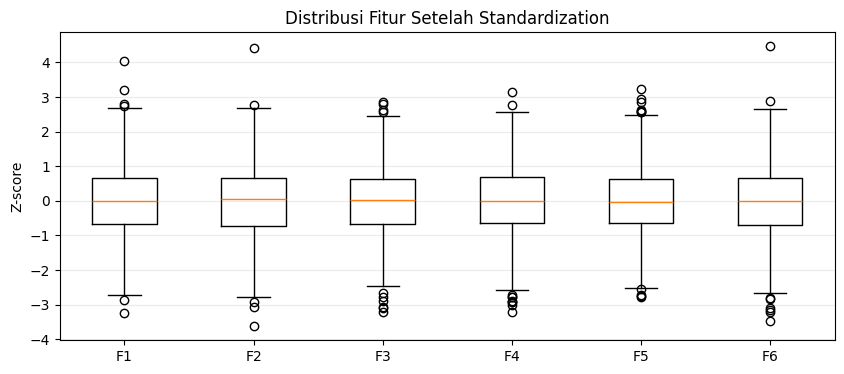

Caption: Setelah standardisasi, skala keenam fitur berada pada rentang yang sebanding sehingga tidak ada fitur yang mendominasi hanya karena satuannya lebih besar.


In [2]:
fig, ax = plt.subplots(figsize=(10,4))
ax.boxplot(X, labels=[f"F{i}" for i in range(1,7)])
ax.set_title("Distribusi Fitur Setelah Standardization")
ax.set_ylabel("Z-score")
ax.grid(axis="y", alpha=.25)
plt.show()
print("Caption: Setelah standardisasi, skala keenam fitur berada pada rentang yang sebanding sehingga tidak ada fitur yang mendominasi hanya karena satuannya lebih besar.")


## 3. PCA sebagai Konteks — Bukan Model Utama

PCA pada buku digunakan untuk menemukan kombinasi linear yang menjelaskan variasi data. Dalam notebook DL ini, PCA hanya dipakai sebagai **referensi konseptual**.

Autoencoder memiliki tujuan yang mirip dalam dimensionality reduction, tetapi representasinya dapat bersifat **nonlinear** karena menggunakan activation function seperti ReLU.

Perbedaan inti:
- **PCA:** transformasi linear.
- **Autoencoder:** transformasi learned dan dapat nonlinear.
- Keduanya dapat menghasilkan representasi berdimensi lebih rendah.


In [3]:
print("Proporsi variance PCA:")
for i, v in enumerate(explained[:4], 1):
    print(f"PC{i}: {v:.3f}")


Proporsi variance PCA:
PC1: 0.502
PC2: 0.478
PC3: 0.008
PC4: 0.006


## 4. Arsitektur Autoencoder

Arsitektur yang digunakan:

**6 input → 24 Dense + ReLU → 2-dimensional bottleneck → 24 Dense + ReLU → 6 output**

Bottleneck memaksa jaringan menyimpan informasi penting ke dalam hanya dua angka untuk setiap observasi. Ini merupakan bentuk **representation learning**.


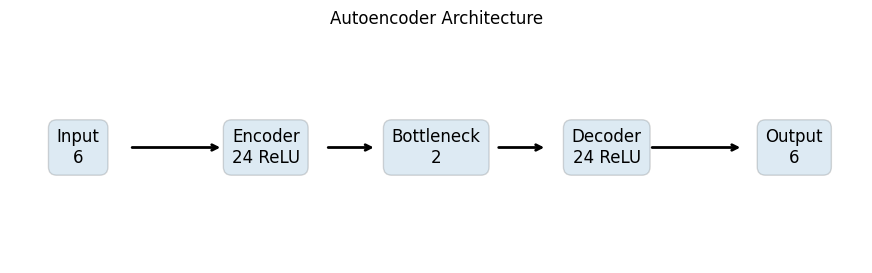

Caption: Encoder memampatkan input ke latent space 2D; decoder mencoba merekonstruksi kembali enam fitur awal.


In [4]:
fig, ax = plt.subplots(figsize=(11,3))
layers = [("Input\n6",0.08),("Encoder\n24 ReLU",0.30),("Bottleneck\n2",0.50),("Decoder\n24 ReLU",0.70),("Output\n6",0.92)]
for label,x in layers:
    ax.text(x,.5,label,ha="center",va="center",fontsize=12,
            bbox=dict(boxstyle="round,pad=.5",alpha=.15))
for x1,x2 in [(0.14,.25),(.37,.43),(.57,.63),(.75,.86)]:
    ax.annotate("",xy=(x2,.5),xytext=(x1,.5),arrowprops=dict(arrowstyle="->",lw=2))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
ax.set_title("Autoencoder Architecture")
plt.show()
print("Caption: Encoder memampatkan input ke latent space 2D; decoder mencoba merekonstruksi kembali enam fitur awal.")


## 5. Training Autoencoder

Loss utama adalah **Mean Squared Error (MSE)** antara input dan hasil reconstruction:

\[
MSE = \frac{1}{n}\sum_{i=1}^{n}(x_i-\hat{x}_i)^2
\]

Karena tidak ada label, reconstruction error menjadi sinyal utama untuk belajar.


In [5]:
print("Final training MSE:", round(hist["loss"][-1], 5))
print("Final validation MSE:", round(hist["val_loss"][-1], 5))
print("Test reconstruction MSE:", round(mse, 5))


Final training MSE: 0.02337
Final validation MSE: 0.02526
Test reconstruction MSE: 0.02481


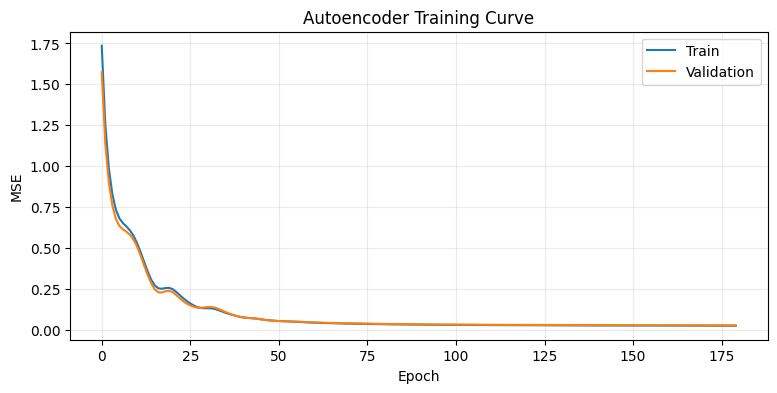

Caption: Kurva menunjukkan apakah reconstruction error menurun dan apakah performa validation mengikuti training tanpa gap yang berlebihan.


In [6]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(hist["loss"], label="Train")
ax.plot(hist["val_loss"], label="Validation")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.set_title("Autoencoder Training Curve")
ax.legend(); ax.grid(alpha=.25)
plt.show()
print("Caption: Kurva menunjukkan apakah reconstruction error menurun dan apakah performa validation mengikuti training tanpa gap yang berlebihan.")


## 6. Latent Representation

Setelah training, encoder dapat digunakan sebagai feature extractor. Setiap observasi yang awalnya memiliki enam fitur sekarang direpresentasikan sebagai dua latent features.

Representasi ini dapat digunakan untuk:
- visualisasi data;
- feature extraction;
- preprocessing sebelum model supervised;
- menemukan struktur tersembunyi dalam data.


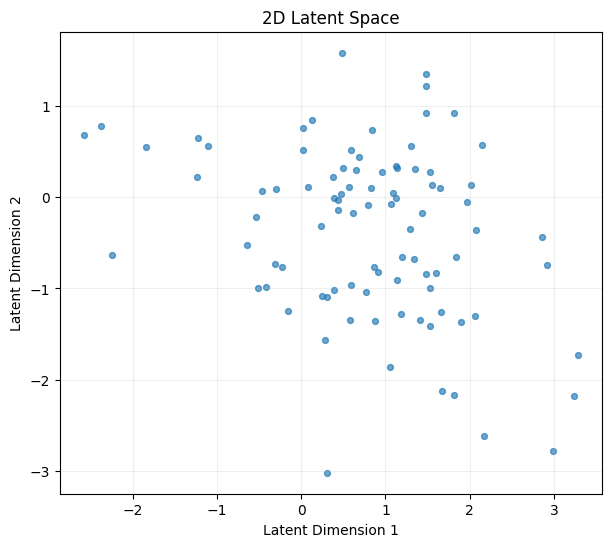

Caption: Setiap titik adalah satu observasi yang dipetakan ke latent space 2D oleh encoder. Struktur/kelompok yang terlihat berasal dari representasi yang dipelajari, bukan label yang diberikan.


In [7]:
fig, ax = plt.subplots(figsize=(7,6))
sc=ax.scatter(Zte[:,0],Zte[:,1],s=18,alpha=.65)
ax.set_xlabel("Latent Dimension 1")
ax.set_ylabel("Latent Dimension 2")
ax.set_title("2D Latent Space")
ax.grid(alpha=.2)
plt.show()
print(f"Caption: Setiap titik adalah satu observasi yang dipetakan ke latent space 2D oleh encoder. Struktur/kelompok yang terlihat berasal dari representasi yang dipelajari, bukan label yang diberikan.")


## 7. Reconstruction Quality

Kita membandingkan data asli dengan data hasil decoder. Reconstruction yang baik berarti latent representation berhasil mempertahankan informasi penting dari input.

Selain MSE, notebook menghitung proporsi variasi yang berhasil dipertahankan secara sederhana:

\[
1-\frac{MSE_{reconstruction}}{Var(X)}
\]

Nilai ini digunakan sebagai ukuran deskriptif, bukan sebagai pengganti metrik evaluasi universal untuk semua Autoencoder.


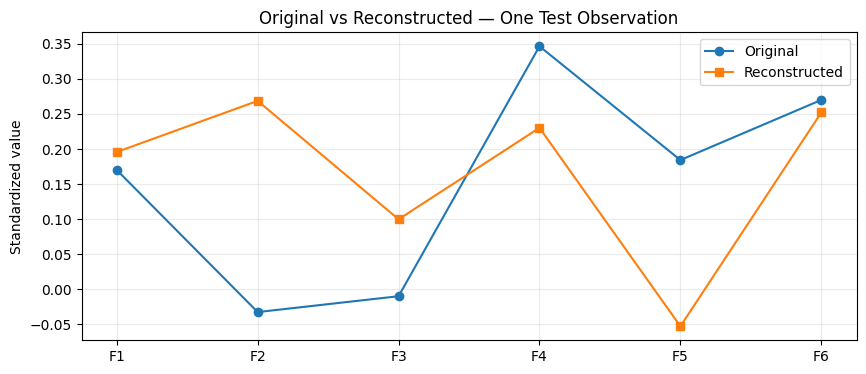

Caption: Garis menunjukkan seberapa dekat decoder merekonstruksi satu observasi test. Test MSE = 0.02481.
Reconstruction variance-retention proxy = 0.977


In [8]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(Xte[0],marker="o",label="Original")
ax.plot(recon[0],marker="s",label="Reconstructed")
ax.set_xticks(range(6),[f"F{i}" for i in range(1,7)])
ax.set_ylabel("Standardized value")
ax.set_title("Original vs Reconstructed — One Test Observation")
ax.legend(); ax.grid(alpha=.25)
plt.show()
print(f"Caption: Garis menunjukkan seberapa dekat decoder merekonstruksi satu observasi test. Test MSE = {mse:.5f}.")
print(f"Reconstruction variance-retention proxy = {relative:.3f}")


## 8. Model Capacity

Capacity menentukan seberapa kompleks pola yang dapat dipelajari. Model terlalu kecil dapat mengalami underfitting, sedangkan model yang terlalu besar dapat lebih mudah menghafal pola training.

Eksperimen berikut membandingkan jumlah neuron hidden layer: **8, 24, dan 64**.


In [9]:
display(cap_df.round(5))


,Model,Hidden units,Train MSE,Validation MSE
0,Small,8,0.04367,0.04901
1,Baseline,24,0.02449,0.02618
2,Large,64,0.02606,0.02864


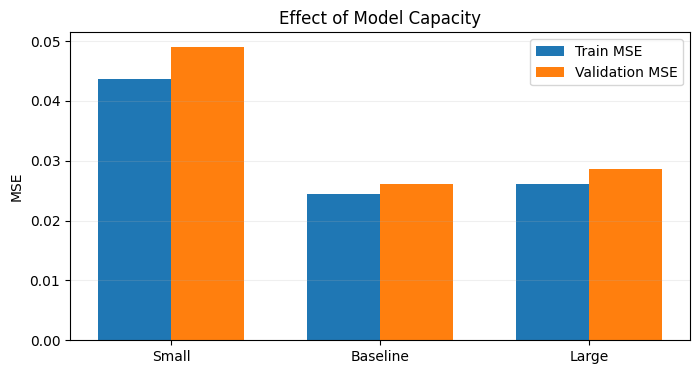

Caption: Perbandingan train dan validation MSE membantu melihat trade-off kapasitas model dan generalisasi.


In [10]:
fig, ax = plt.subplots(figsize=(8,4))
x=np.arange(len(cap_df))
w=.35
ax.bar(x-w/2,cap_df["Train MSE"],w,label="Train MSE")
ax.bar(x+w/2,cap_df["Validation MSE"],w,label="Validation MSE")
ax.set_xticks(x,cap_df["Model"])
ax.set_ylabel("MSE"); ax.set_title("Effect of Model Capacity")
ax.legend(); ax.grid(axis="y",alpha=.2)
plt.show()
print("Caption: Perbandingan train dan validation MSE membantu melihat trade-off kapasitas model dan generalisasi.")


## 9. Regularization dengan L2

L2 regularization menambahkan penalti terhadap bobot besar:

\[
L = MSE + \lambda\sum W^2
\]

Tujuannya adalah mendorong model menghasilkan solusi yang lebih sederhana dan dapat membantu mengurangi overfitting.


In [11]:
display(reg_df.round(6))


,L2,Train MSE,Validation MSE
0,0.0000,0.024495,0.026183
1,0.0001,0.024505,0.026124
2,0.0010,0.024620,0.025824
3,0.0100,0.028494,0.030530


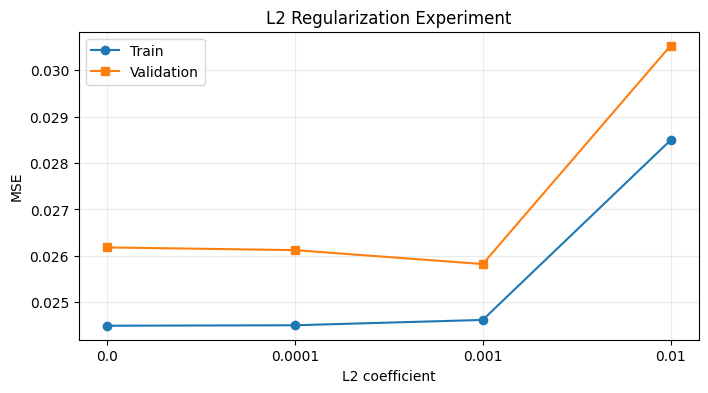

Caption: Perubahan koefisien L2 menunjukkan bagaimana penalti bobot memengaruhi reconstruction pada train dan validation set.


In [12]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(reg_df["L2"].astype(str),reg_df["Train MSE"],marker="o",label="Train")
ax.plot(reg_df["L2"].astype(str),reg_df["Validation MSE"],marker="s",label="Validation")
ax.set_xlabel("L2 coefficient"); ax.set_ylabel("MSE")
ax.set_title("L2 Regularization Experiment")
ax.legend(); ax.grid(alpha=.25)
plt.show()
print("Caption: Perubahan koefisien L2 menunjukkan bagaimana penalti bobot memengaruhi reconstruction pada train dan validation set.")


## 10. Hubungan dengan Clustering

Chapter 7 membahas K-Means, hierarchical clustering, dan model-based clustering sebagai cara menemukan kelompok tanpa label. citeturn0search1

Dalam workflow DL, latent space Autoencoder dapat menjadi **representation space** yang kemudian dianalisis lebih lanjut. Namun, pada notebook ini kita tidak menjalankan K-Means sebagai model utama karena fokus tugas adalah Deep Learning.

Intinya:
**Raw features → Autoencoder Encoder → Latent representation → analisis struktur data**


In [13]:
print("Latent representation shape:", Zte.shape)
print("Rata-rata absolute correlation latent ↔ latent factors:", round(latent_corr,3))
print("Catatan: korelasi ini hanya diagnostik pada data sintetis; pada data nyata latent dimensions tidak otomatis memiliki makna semantik tertentu.")


Latent representation shape: (90, 2)
Rata-rata absolute correlation latent ↔ latent factors: 0.572
Catatan: korelasi ini hanya diagnostik pada data sintetis; pada data nyata latent dimensions tidak otomatis memiliki makna semantik tertentu.


## 11. Hyperparameter yang Penting

Untuk Autoencoder, beberapa hyperparameter utama adalah:
- **Bottleneck dimension:** menentukan seberapa agresif dimensionality reduction.
- **Hidden units:** mengontrol kapasitas representasi.
- **Learning rate:** menentukan ukuran langkah optimisasi.
- **Epochs:** jumlah iterasi pembelajaran.
- **L2 coefficient:** mengontrol regularisasi.
- **Activation function:** memengaruhi kemampuan model menangkap hubungan nonlinear.

Pemilihan hyperparameter sebaiknya menggunakan validation set atau cross-validation yang sesuai dengan tujuan analisis.


## 12. Workflow DL untuk Unsupervised Learning

Workflow yang dapat digunakan pada kasus nyata:

1. pahami struktur dan skala fitur;
2. lakukan preprocessing/scaling;
3. pisahkan data untuk training dan evaluasi;
4. tentukan bottleneck dan kapasitas jaringan;
5. train Autoencoder;
6. monitor reconstruction loss;
7. evaluasi reconstruction pada data yang tidak digunakan untuk training;
8. visualisasikan latent representation;
9. gunakan latent features untuk analisis lanjutan jika diperlukan.

**Catatan:** tanpa label, evaluasi tidak sesederhana accuracy/AUC pada supervised learning. Karena itu reconstruction quality dan usefulness dari latent representation menjadi penting.


## 13. Ringkasan Chapter 7

- Unsupervised learning bekerja tanpa target/label.
- Chapter 7 membahas dimensionality reduction dan clustering. citeturn0search1
- Untuk fokus Deep Learning, **Autoencoder** merupakan metode utama notebook ini.
- Encoder menghasilkan latent representation berdimensi lebih rendah.
- Decoder merekonstruksi input.
- MSE dapat digunakan sebagai reconstruction loss.
- Bottleneck dan kapasitas jaringan mengontrol trade-off antara kompresi dan informasi yang dipertahankan.
- L2 regularization membantu mengontrol kompleksitas model.
- Latent representation dapat digunakan sebagai feature representation untuk analisis berikutnya.

### Takeaway
**PCA → linear dimensionality reduction**

**Autoencoder → learned nonlinear representation**

**Clustering → mencari struktur/kelompok pada data tanpa label**
